<a href="https://colab.research.google.com/github/Danishkodavanti/ML_Lab/blob/main/Lab_Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Create synthetic dataset
np.random.seed(42)

data = {
    "Age": np.random.randint(18, 60, 100),
    "Income": np.random.randint(20000, 100000, 100),
    "SpendingScore": np.random.randint(1, 100, 100)
}

df = pd.DataFrame(data)

# Save as CSV
df.to_csv("customer_data.csv", index=False)

print("Dataset created successfully!")
df.head()

Dataset created successfully!


,Age,Income,SpendingScore
0,56,28392,19
1,46,50535,20
2,32,98603,96
3,25,72256,71
4,38,55222,52


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("customer_data.csv")

# Select features (Income & Spending Score)
X = df[['Income', 'SpendingScore']].values

# Number of clusters
k = 4

# Initialize centroids randomly
np.random.seed(42)
centroids = X[np.random.choice(X.shape[0], k, replace=False)]

# Function to calculate Euclidean distance
def distance(a, b):
    return np.linalg.norm(a - b)

# K-Means algorithm
for iteration in range(100):
    clusters = [[] for _ in range(k)]

    # Assign points to nearest centroid
    for point in X:
        distances = [distance(point, centroid) for centroid in centroids]
        cluster_index = np.argmin(distances)
        clusters[cluster_index].append(point)

    # Store old centroids
    old_centroids = centroids.copy()

    # Update centroids
    for i in range(k):
        if clusters[i]:
            centroids[i] = np.mean(clusters[i], axis=0)

    # Stop if centroids don't change
    if np.all(old_centroids == centroids):
        break

# Convert clusters to numpy arrays
clusters = [np.array(cluster) for cluster in clusters]

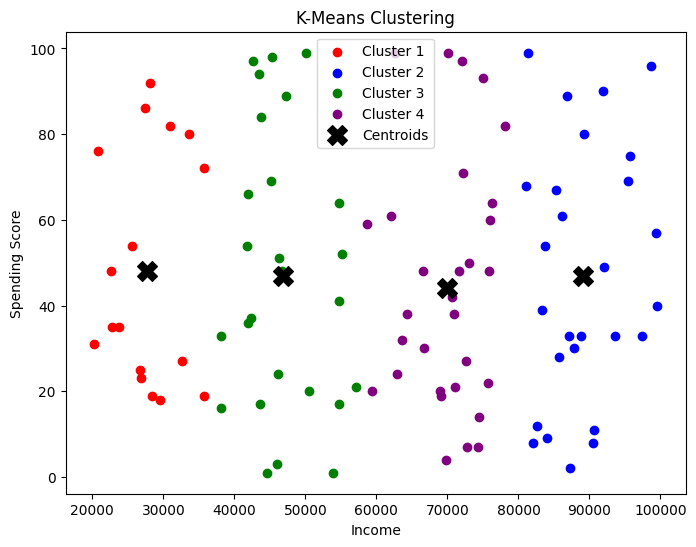

In [3]:
colors = ['red', 'blue', 'green', 'purple']

plt.figure(figsize=(8,6))

for i in range(k):
    if len(clusters[i]) > 0:
        plt.scatter(clusters[i][:,0], clusters[i][:,1],
                    c=colors[i], label=f'Cluster {i+1}')

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1],
            c='black', marker='X', s=200, label='Centroids')

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.legend()
plt.show()